In [31]:
# import random

# def objective_function(x):
#     return sum([xi**2 for xi in x])

# def initialize_population(pop_size, bounds):
#     population = []
#     for _ in range(pop_size):
#         individual = [random.uniform(b[0], b[1]) for b in bounds]
#         population.append(individual)
#     return population

# def get_neighbors(solution, bounds):
#     neighbor = solution[:]
#     idx = random.randint(0, len(bounds) - 1)
#     neighbor[idx] = random.uniform(bounds[idx][0], bounds[idx][1])
#     return neighbor

# def bee_algorithm(func, bounds, pop_size=10, max_iter=1000):
#     population = initialize_population(pop_size, bounds)
#     fitness = [func(ind) for ind in population]
    
#     for _ in range(max_iter):
#         # Employed bees phase
#         for i in range(pop_size):
#             neighbor = get_neighbors(population[i], bounds)
#             neighbor_fitness = func(neighbor)
#             if neighbor_fitness < fitness[i]:
#                 population[i] = neighbor
#                 fitness[i] = neighbor_fitness

#         # Onlooker bees phase
#         fitness_sum = sum(fitness)
#         probabilities = [f / fitness_sum for f in fitness]
#         for i in range(pop_size):
#             if random.random() < probabilities[i]:
#                 neighbor = get_neighbors(population[i], bounds)
#                 neighbor_fitness = func(neighbor)
#                 if neighbor_fitness < fitness[i]:
#                     population[i] = neighbor
#                     fitness[i] = neighbor_fitness

#         # Scout bees phase
#         for i in range(pop_size):
#             if random.random() < 0.1:  # Scout probability
#                 population[i] = [random.uniform(b[0], b[1]) for b in bounds]
#                 fitness[i] = func(population[i])

#     best_index = fitness.index(min(fitness))
#     return population[best_index], fitness[best_index]

# # Example usage
# bounds = [(-5, 5), (-5, 5)]
# best_solution, best_value = bee_algorithm(objective_function, bounds, max_iter=1000)
# print(f"Best solution: {best_solution}")
# print(f"Best value: {best_value}")

In [32]:
# import random
# import math

# # ==========================
# # Objective Function
# # ==========================
# def objective_function(x):
#     """
#     Contoh fungsi minimisasi:
#     f(x) = x1^2 + x2^2 + ... + xn^2
#     """
#     return sum(xi**2 for xi in x)

# # ==========================
# # Fitness Transformation
# # ==========================
# def calculate_fitness(obj_value):
#     """
#     Transformasi fitness standar ABC (minimisasi)
#     """
#     if obj_value >= 0:
#         return 1 / (1 + obj_value)
#     else:
#         return 1 + abs(obj_value)

# # ==========================
# # Initialization
# # ==========================
# def initialize_population(food_number, bounds, dim):
#     population = []
#     fitness = []
#     trial = []

#     for _ in range(food_number):
#         solution = [
#             random.uniform(bounds[j][0], bounds[j][1])
#             for j in range(dim)
#         ]
#         obj_val = objective_function(solution)
#         population.append(solution)
#         fitness.append(calculate_fitness(obj_val))
#         trial.append(0)

#     return population, fitness, trial

# # ==========================
# # Generate Neighbor Solution
# # ==========================
# def generate_neighbor(solution, population, bounds):
#     dim = len(solution)
#     j = random.randint(0, dim - 1)

#     k = random.randint(0, len(population) - 1)
#     while population[k] == solution:
#         k = random.randint(0, len(population) - 1)

#     phi = random.uniform(-1, 1)

#     neighbor = solution.copy()
#     neighbor[j] = solution[j] + phi * (solution[j] - population[k][j])

#     # Boundary check
#     neighbor[j] = max(bounds[j][0], min(neighbor[j], bounds[j][1]))

#     return neighbor

# # ==========================
# # Main ABC Algorithm
# # ==========================
# def artificial_bee_colony(
#     bounds,
#     food_number=10,
#     limit=20,
#     max_iter=1000
# ):
#     dim = len(bounds)

#     # Initialization
#     population, fitness, trial = initialize_population(
#         food_number, bounds, dim
#     )

#     best_solution = None
#     best_obj = float("inf")

#     for _ in range(max_iter):

#         # ===== Employed Bee Phase =====
#         for i in range(food_number):
#             neighbor = generate_neighbor(
#                 population[i], population, bounds
#             )

#             obj_new = objective_function(neighbor)
#             fit_new = calculate_fitness(obj_new)

#             if fit_new > fitness[i]:  # greedy selection
#                 population[i] = neighbor
#                 fitness[i] = fit_new
#                 trial[i] = 0
#             else:
#                 trial[i] += 1

#         # ===== Onlooker Bee Phase =====
#         fitness_sum = sum(fitness)
#         probabilities = [f / fitness_sum for f in fitness]

#         i = 0
#         counter = 0
#         while counter < food_number:
#             if random.random() < probabilities[i]:
#                 neighbor = generate_neighbor(
#                     population[i], population, bounds
#                 )

#                 obj_new = objective_function(neighbor)
#                 fit_new = calculate_fitness(obj_new)

#                 if fit_new > fitness[i]:
#                     population[i] = neighbor
#                     fitness[i] = fit_new
#                     trial[i] = 0
#                 else:
#                     trial[i] += 1

#                 counter += 1

#             i = (i + 1) % food_number

#         # ===== Scout Bee Phase =====
#         for i in range(food_number):
#             if trial[i] > limit:
#                 population[i] = [
#                     random.uniform(bounds[j][0], bounds[j][1])
#                     for j in range(dim)
#                 ]
#                 obj_val = objective_function(population[i])
#                 fitness[i] = calculate_fitness(obj_val)
#                 trial[i] = 0

#         # ===== Save Best Solution =====
#         for i in range(food_number):
#             obj_val = objective_function(population[i])
#             if obj_val < best_obj:
#                 best_obj = obj_val
#                 best_solution = population[i].copy()

#     return best_solution, best_obj

# # ==========================
# # Example Usage
# # ==========================
# if __name__ == "__main__":
#     bounds = [(-5, 5), (-5, 5)]
#     best_solution, best_value = artificial_bee_colony(
#         bounds,
#         food_number=20,
#         limit=50,
#         max_iter=1000
#     )

#     print("Best Solution :", best_solution)
#     print("Best Objective:", best_value)


In [33]:
import pandas as pd
df= pd.read_excel('Data_PT. Amanah_Critical_Break.xlsx')
# df = df[df['Status'].isin(["Critical", "Break"])]
df=df[df['Status']=="Critical"] 
df.head(15)

,Exhaust Gas Temperature LF (Left Front),Exhaust Gas Temperature LR (Left Rear),Exhaust Gas Temperature RF (Right Front),Exhaust Gas Temperature RR (Right Rear),Blowby Pressure (Kpa),Boost Pressure (Kpa),Engine Oil Temp (°C),Coolant Temp (°C),Unit Lifetime (Hour),Status,sisa jam
328,704.33,666.686,659.947,750,4.537,145.09,117.128,102.619,76473,Critical,2164.0
403,688.297,750,733.196,642.027,5.509,166.996,124.477,109.764,76548,Critical,2089.0
405,693.454,750,730.53,646.575,5.569,165.516,122.693,110,76550,Critical,2087.0
410,688.051,750,736.907,666.809,6.206,156.452,125.636,109.053,76555,Critical,2082.0
411,689.735,750,739.911,681.378,6.224,156.855,125.152,109.758,76556,Critical,2081.0
417,672.136,730.335,750,713.521,5.4,156.13,122.16,107.613,76562,Critical,2075.0
427,679.126,732.495,703.755,710.776,4.966,157.846,128,107.251,76572,Critical,2065.0
429,678.777,734.138,718.713,718.473,4.601,157.035,128,106.787,76574,Critical,2063.0
430,683.581,735.55,716.101,719.533,4.606,156.366,128,105.212,76575,Critical,2062.0
431,690.26,731.316,713.622,708.636,4.779,156.147,128,104.328,76576,Critical,2061.0


In [34]:
df=df.drop(columns='Status')
df=df.drop(columns='Unit Lifetime (Hour)')

In [35]:
df = df.astype({
    'Exhaust Gas Temperature LF (Left Front)': 'float',
    'Exhaust Gas Temperature LR (Left Rear)': 'float',
    'Exhaust Gas Temperature RF (Right Front)': 'float',
    'Exhaust Gas Temperature RR (Right Rear)': 'float',
    'Blowby Pressure (Kpa)': 'float',
    'Boost Pressure (Kpa)': 'float',
    'Engine Oil Temp (°C)': 'float',
    'Coolant Temp (°C)': 'float',
    
    'sisa jam':'float'
})

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 645 entries, 328 to 2491
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Exhaust Gas Temperature LF (Left Front)   645 non-null    float64
 1   Exhaust Gas Temperature LR (Left Rear)    645 non-null    float64
 2   Exhaust Gas Temperature RF (Right Front)  645 non-null    float64
 3   Exhaust Gas Temperature RR (Right Rear)   645 non-null    float64
 4   Blowby Pressure (Kpa)                     645 non-null    float64
 5   Boost Pressure (Kpa)                      645 non-null    float64
 6   Engine Oil Temp (°C)                      645 non-null    float64
 7   Coolant Temp (°C)                         645 non-null    float64
 8   sisa jam                                  645 non-null    float64
dtypes: float64(9)
memory usage: 50.4 KB


In [37]:
df_numeric = df.select_dtypes(include='number')
df_cor=df_numeric.corr()
# Membulatkan nilai korelasi menjadi 2 angka di belakang koma
df_cor_rounded = df_cor.round(2)

# Menyimpan ke file Excel
# df_cor_rounded.to_excel('hasil_korelasi.xlsx', index=True)
df_cor_rounded
# print("File 'hasil_korelasi.xlsx' berhasil disimpan!")

,Exhaust Gas Temperature LF (Left Front),Exhaust Gas Temperature LR (Left Rear),Exhaust Gas Temperature RF (Right Front),Exhaust Gas Temperature RR (Right Rear),Blowby Pressure (Kpa),Boost Pressure (Kpa),Engine Oil Temp (°C),Coolant Temp (°C),sisa jam
Exhaust Gas Temperature LF (Left Front),1.00,0.25,0.21,0.27,0.14,0.19,0.52,-0.05,-0.23
Exhaust Gas Temperature LR (Left Rear),0.25,1.00,0.39,0.13,0.37,0.25,0.21,0.01,-0.14
Exhaust Gas Temperature RF (Right Front),0.21,0.39,1.00,0.19,0.34,0.12,0.23,-0.13,-0.11
Exhaust Gas Temperature RR (Right Rear),0.27,0.13,0.19,1.00,0.38,0.28,0.10,-0.09,-0.43
Blowby Pressure (Kpa),0.14,0.37,0.34,0.38,1.00,0.53,0.17,0.17,-0.61
Boost Pressure (Kpa),0.19,0.25,0.12,0.28,0.53,1.00,0.26,0.51,-0.67
Engine Oil Temp (°C),0.52,0.21,0.23,0.10,0.17,0.26,1.00,0.05,-0.24
Coolant Temp (°C),-0.05,0.01,-0.13,-0.09,0.17,0.51,0.05,1.00,-0.20
sisa jam,-0.23,-0.14,-0.11,-0.43,-0.61,-0.67,-0.24,-0.20,1.00


### RANDOM FOREST

Epoch 1/30 | Best CV MSE: 35405.1171
Epoch 2/30 | Best CV MSE: 35369.0580
Epoch 3/30 | Best CV MSE: 35327.2078
Epoch 4/30 | Best CV MSE: 34411.9252
Epoch 5/30 | Best CV MSE: 34411.9252
Epoch 6/30 | Best CV MSE: 34185.4631
Epoch 7/30 | Best CV MSE: 31553.0157
Epoch 8/30 | Best CV MSE: 30453.8774
Epoch 9/30 | Best CV MSE: 30111.3398
Epoch 10/30 | Best CV MSE: 29385.1294
Epoch 11/30 | Best CV MSE: 29385.1294
Epoch 12/30 | Best CV MSE: 29385.1294
Epoch 13/30 | Best CV MSE: 29385.1294
Epoch 14/30 | Best CV MSE: 29385.1294
Epoch 15/30 | Best CV MSE: 29385.1294
Epoch 16/30 | Best CV MSE: 29385.1294
Epoch 17/30 | Best CV MSE: 29385.1294
Epoch 18/30 | Best CV MSE: 29385.1294
Epoch 19/30 | Best CV MSE: 29385.1294
Epoch 20/30 | Best CV MSE: 29385.1294
Epoch 21/30 | Best CV MSE: 29385.1294
Epoch 22/30 | Best CV MSE: 29385.1294
Epoch 23/30 | Best CV MSE: 29385.1294
Epoch 24/30 | Best CV MSE: 29385.1294
Epoch 25/30 | Best CV MSE: 29385.1294
Epoch 26/30 | Best CV MSE: 29385.1294
Epoch 27/30 | Best CV

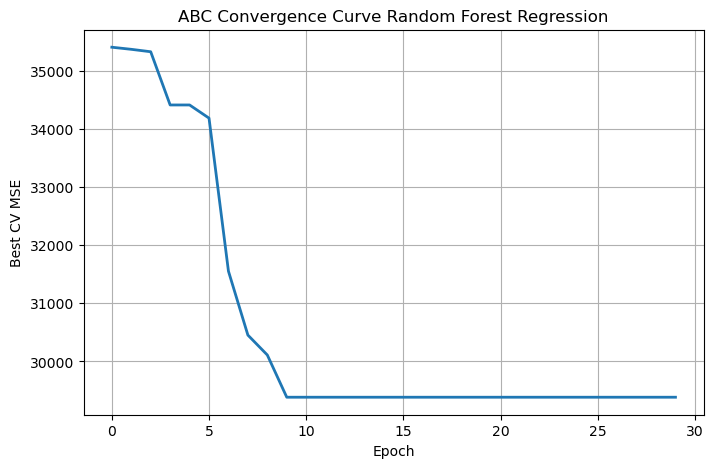

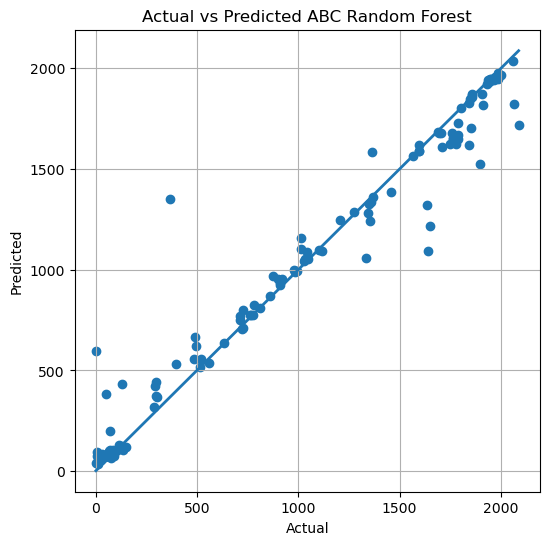

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, r2_score


X = df.drop("sisa jam", axis=1)  
y = df["sisa jam"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


param_bounds = {
    "n_estimators": (50, 300),
    "max_depth": (2, 30),
    "min_samples_split": (2, 20),
    "min_samples_leaf": (1, 20),
    "max_features": (0.1, 1.0)
}

param_keys = list(param_bounds.keys())
dim = len(param_keys)


def decode_solution(solution):
    return {
        "n_estimators": int(solution[0]),
        "max_depth": int(solution[1]),
        "min_samples_split": int(solution[2]),
        "min_samples_leaf": int(solution[3]),
        "max_features": solution[4]
    }


def objective_function(solution):

    params = decode_solution(solution)

    model = RandomForestRegressor(
        **params,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_squared_error"
    )

    mse = -scores.mean()

    return mse



def calculate_fitness(obj_value):
    return 1 / (1 + obj_value)



def initialize_population(food_number):

    population = []
    fitness = []
    trial = []

    for _ in range(food_number):

        solution = [
            random.uniform(param_bounds[k][0], param_bounds[k][1])
            for k in param_keys
        ]

        obj = objective_function(solution)

        population.append(solution)
        fitness.append(calculate_fitness(obj))
        trial.append(0)

    return population, fitness, trial



def generate_neighbor(solution, population):

    j = random.randint(0, dim - 1)

    k = random.randint(0, len(population) - 1)
    while population[k] == solution:
        k = random.randint(0, len(population) - 1)

    phi = random.uniform(-1, 1)

    neighbor = solution.copy()

    neighbor[j] = solution[j] + phi * (solution[j] - population[k][j])

    low, high = param_bounds[param_keys[j]]

    neighbor[j] = max(low, min(neighbor[j], high))

    return neighbor



def artificial_bee_colony(
    food_number=15,
    limit=5,
    max_iter=30
):

    population, fitness, trial = initialize_population(food_number)

    best_solution = None
    best_obj = float("inf")

    convergence_curve = []

    for iteration in range(max_iter):

        
        for i in range(food_number):

            neighbor = generate_neighbor(population[i], population)

            obj_new = objective_function(neighbor)
            fit_new = calculate_fitness(obj_new)

            if fit_new > fitness[i]:

                population[i] = neighbor
                fitness[i] = fit_new
                trial[i] = 0

            else:
                trial[i] += 1


        
        prob = np.array(fitness) / np.sum(fitness)

        counter = 0
        i = 0

        while counter < food_number:

            if random.random() < prob[i]:

                neighbor = generate_neighbor(population[i], population)

                obj_new = objective_function(neighbor)
                fit_new = calculate_fitness(obj_new)

                if fit_new > fitness[i]:

                    population[i] = neighbor
                    fitness[i] = fit_new
                    trial[i] = 0

                else:
                    trial[i] += 1

                counter += 1

            i = (i + 1) % food_number


        
        for i in range(food_number):

            if trial[i] > limit:

                population[i] = [
                    random.uniform(param_bounds[k][0], param_bounds[k][1])
                    for k in param_keys
                ]

                obj = objective_function(population[i])

                fitness[i] = calculate_fitness(obj)
                trial[i] = 0


        # Save Best
        for sol in population:

            obj = objective_function(sol)

            if obj < best_obj:

                best_obj = obj
                best_solution = sol.copy()


        convergence_curve.append(best_obj)

        print(
            f"Epoch {iteration+1}/{max_iter} | Best CV MSE: {best_obj:.4f}"
        )


    return decode_solution(best_solution), best_obj, convergence_curve

# RUN ABC Optimization
best_params, best_mse, convergence = artificial_bee_colony(
    food_number=15,
    limit=5,
    max_iter=30
)

best_rmse = np.sqrt(best_mse)


# Train Final Model
model = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)

from sklearn.metrics import mean_absolute_error, r2_score

test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)



print("\n=== Best Hyperparameters (ABC - Random Forest) ===")

for key, value in best_params.items():
    print(f"{key:<18}: {value}")

print(f"Best CV MSE        : {best_mse}")
print(f"Best CV RMSE       : {best_rmse}")


print("\n=== Final Test Evaluation (20%) ===")

print(f"MSE  : {test_mse}")
print(f"RMSE : {test_rmse}")
print(f"MAE  : {test_mae}")
print(f"R²   : {test_r2}")


# Plot Convergence Curve

plt.figure(figsize=(8,5))

plt.plot(convergence, linewidth=2)

plt.title("ABC Convergence Curve Random Forest Regression")
plt.xlabel("Epoch")
plt.ylabel("Best CV MSE")

plt.grid()

plt.show()



# Scatter Plot Actual vs Predicted

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=2
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted ABC Random Forest")

plt.grid()

plt.show()

### SVR/SVM

Epoch 1/40 | Best CV MSE: 15253.369540
Epoch 2/40 | Best CV MSE: 14677.274618
Epoch 3/40 | Best CV MSE: 14277.014349
Epoch 4/40 | Best CV MSE: 14277.014349
Epoch 5/40 | Best CV MSE: 13085.774871
Epoch 6/40 | Best CV MSE: 13033.385646
Epoch 7/40 | Best CV MSE: 12623.395389
Epoch 8/40 | Best CV MSE: 12582.004578
Epoch 9/40 | Best CV MSE: 12220.248331
Epoch 10/40 | Best CV MSE: 12150.093568
Epoch 11/40 | Best CV MSE: 12111.356555
Epoch 12/40 | Best CV MSE: 12111.356555
Epoch 13/40 | Best CV MSE: 12111.356555
Epoch 14/40 | Best CV MSE: 12111.356555
Epoch 15/40 | Best CV MSE: 12111.356555
Epoch 16/40 | Best CV MSE: 12111.356555
Epoch 17/40 | Best CV MSE: 12111.356555
Epoch 18/40 | Best CV MSE: 12108.095116
Epoch 19/40 | Best CV MSE: 12030.568563
Epoch 20/40 | Best CV MSE: 12030.568563
Epoch 21/40 | Best CV MSE: 12026.877344
Epoch 22/40 | Best CV MSE: 12026.877344
Epoch 23/40 | Best CV MSE: 12026.877344
Epoch 24/40 | Best CV MSE: 12026.877344
Epoch 25/40 | Best CV MSE: 12026.877344
Epoch 26/

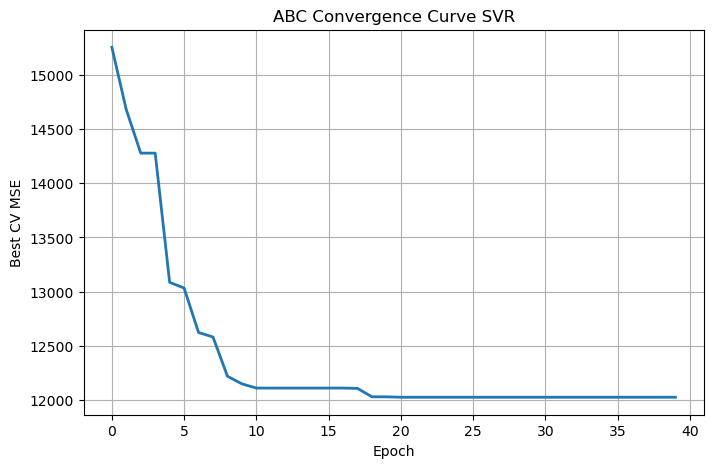

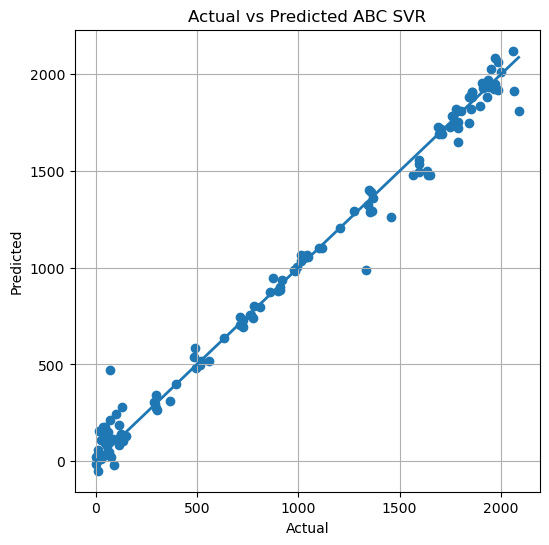

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler



data = fetch_california_housing()

X = df.drop("sisa jam", axis=1) 
y = df["sisa jam"]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler_X = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)


y_train = y_train.values
y_test = y_test.values

param_bounds = {
    "C": (0.1, 1000),
    "epsilon": (0.001, 50),
    "gamma": (0.0001, 1)
}

param_keys = list(param_bounds.keys())
dim = len(param_keys)


def decode_solution(solution):

    return {
        "C": solution[0],
        "epsilon": solution[1],
        "gamma": solution[2],
        "kernel": 'rbf'
    }


def objective_function(solution):

    params = decode_solution(solution)

    model = SVR(**params)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_squared_error"
    )

    mse = -scores.mean()

    return mse


def calculate_fitness(obj):
    return 1 / (1 + obj)


def initialize_population(food_number):

    population = []
    fitness = []
    trial = []

    for _ in range(food_number):

        solution = [
            random.uniform(param_bounds[k][0], param_bounds[k][1])
            for k in param_keys
        ]

        obj = objective_function(solution)

        population.append(solution)
        fitness.append(calculate_fitness(obj))
        trial.append(0)

    return population, fitness, trial


def generate_neighbor(solution, population):

    j = random.randint(0, dim - 1)

    k = random.randint(0, len(population) - 1)

    while population[k] == solution:
        k = random.randint(0, len(population) - 1)

    phi = random.uniform(-1, 1)

    neighbor = solution.copy()

    neighbor[j] = solution[j] + phi * (solution[j] - population[k][j])

    low, high = param_bounds[param_keys[j]]

    neighbor[j] = max(low, min(neighbor[j], high))

    return neighbor


def artificial_bee_colony(
    food_number=15,
    limit=5,
    max_iter=40
):

    population, fitness, trial = initialize_population(food_number)

    best_solution = None
    best_obj = float("inf")

    convergence_curve = []

    for epoch in range(max_iter):

        # Employed Bee
        for i in range(food_number):

            neighbor = generate_neighbor(population[i], population)

            obj_new = objective_function(neighbor)
            fit_new = calculate_fitness(obj_new)

            if fit_new > fitness[i]:

                population[i] = neighbor
                fitness[i] = fit_new
                trial[i] = 0

            else:
                trial[i] += 1

     
        prob = np.array(fitness) / np.sum(fitness)

        counter = 0
        i = 0

        while counter < food_number:

            if random.random() < prob[i]:

                neighbor = generate_neighbor(population[i], population)

                obj_new = objective_function(neighbor)
                fit_new = calculate_fitness(obj_new)

                if fit_new > fitness[i]:

                    population[i] = neighbor
                    fitness[i] = fit_new
                    trial[i] = 0

                else:
                    trial[i] += 1

                counter += 1

            i = (i + 1) % food_number

       
        for i in range(food_number):

            if trial[i] > limit:

                population[i] = [
                    random.uniform(param_bounds[k][0], param_bounds[k][1])
                    for k in param_keys
                ]

                obj = objective_function(population[i])

                fitness[i] = calculate_fitness(obj)
                trial[i] = 0


        # Save Best
        for sol in population:

            obj = objective_function(sol)

            if obj < best_obj:

                best_obj = obj
                best_solution = sol.copy()


        convergence_curve.append(best_obj)

        print(f"Epoch {epoch+1}/{max_iter} | Best CV MSE: {best_obj:.6f}")


    return decode_solution(best_solution), best_obj, convergence_curve



# RUN ABC OPTIMIZATION

best_params, best_mse, convergence = artificial_bee_colony()

best_rmse = np.sqrt(best_mse)



# Train Final Model

model = SVR(**best_params)

model.fit(X_train, y_train)

y_pred= model.predict(X_test)


test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)


print("\n=== Best Hyperparameters (ABC - SVR) ===")

print(f"C        : {best_params['C']}")
print(f"epsilon  : {best_params['epsilon']}")
print(f"gamma    : {best_params['gamma']}")

print(f"Best CV MSE  : {best_mse}")
print(f"Best CV RMSE : {best_rmse}")

print("\n=== Final Test Evaluation (20%) ===")

print(f"MSE  : {test_mse}")
print(f"RMSE : {test_rmse}")
print(f"MAE  : {test_mae}")
print(f"R²   : {test_r2}")



plt.figure(figsize=(8,5))

plt.plot(convergence, linewidth=2)

plt.title("ABC Convergence Curve SVR")

plt.xlabel("Epoch")
plt.ylabel("Best CV MSE")

plt.grid()

plt.show()


# Scatter Plot

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=2
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted ABC SVR")

plt.grid()

plt.show()